Umbralizacion Binaria, y Binaria Inversa.

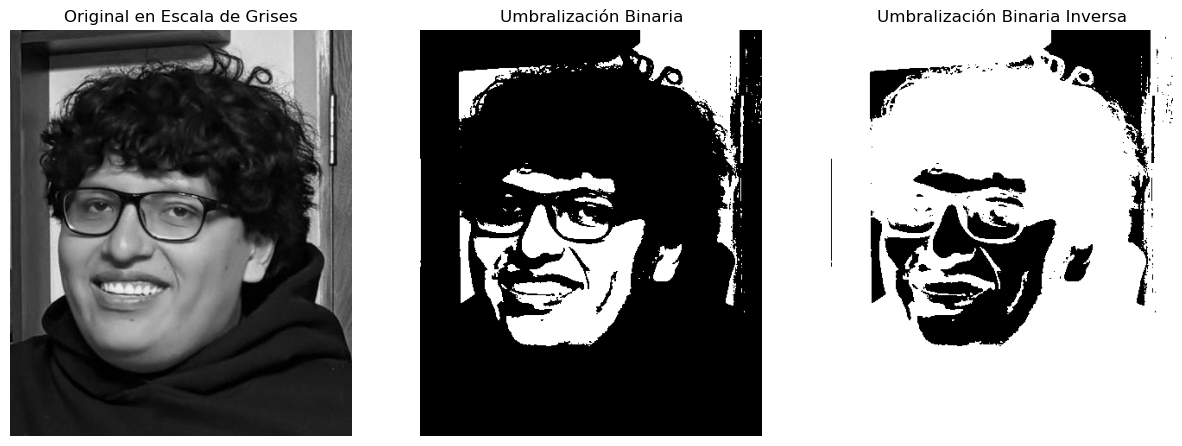

In [3]:
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread('PDI2026/Clase1/chanki.jpg', 0) # lee escala de grises

# umbralizacion binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY) 
_, umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV) 

plt.figure(figsize=(15, 15))
plt.subplot(1, 3, 1), plt.imshow(imagen, cmap='gray'), plt.axis('off'), plt.title('Original en Escala de Grises')
plt.subplot(1, 3, 2), plt.imshow(umbral_binario, cmap='gray'), plt.axis('off'), plt.title('Umbralización Binaria')
plt.subplot(1, 3, 3), plt.imshow(umbral_binario_inv, cmap='gray'), plt.axis('off'), plt.title('Umbralización Binaria Inversa')
plt.show()

UMBRALIZACION GLOBAL UMBRALIZACION ISODATA.

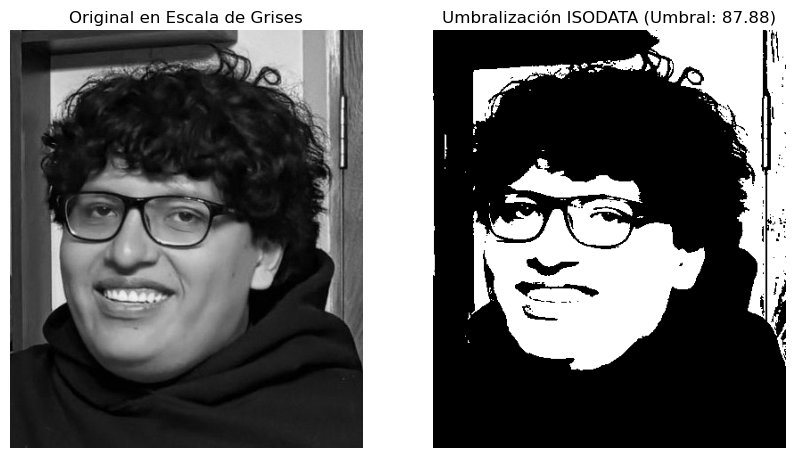

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata(image):
    # Decidimos umbral inicial de 0 a 255
    umbral = 128 
    while True:
        # Dividimos la imagen en dos grupos
        grupo1 = image[image <= umbral] # grupo 1 con valores menores o iguales al umbral
        grupo2 = image[image > umbral] # grupo 2 con valores mayores al umbral

        # Calculamos las medias de ambos grupos
        media1 = np.mean(grupo1) 
        media2 = np.mean(grupo2) 

        # Calculamos el nuevo umbral como la media de las medias
        nuevo_umbral = (media1 + media2) / 2

        # Si el nuevo umbral es igual al umbral inicial, se detiene el proceso
        if abs(nuevo_umbral - umbral) < 0.5: # podemos ajustar este valor para mayor precisión
            break

        umbral = nuevo_umbral
    return umbral

imagen = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
umbral_isodata = isodata(imagen)
_, imagen_umbralizada = cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY) 

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray') 
plt.axis('off')
plt.title('Original en Escala de Grises')

plt.subplot(1, 2, 2)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.axis('off')
plt.title(f'Umbralización ISODATA (Umbral: {umbral_isodata:.2f})')
plt.show()

UMBRALIZACION DE 2 PICOS

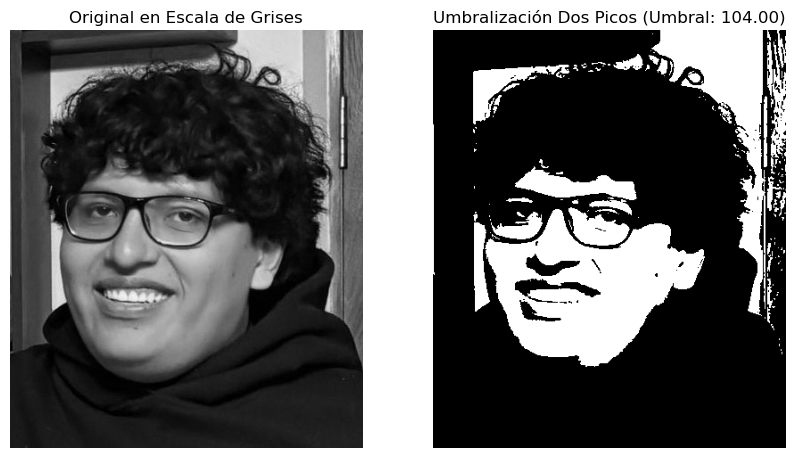

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    # Calculamos el histograma
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]) # usamos el histograma
    # Seleccionamos los dos picos
    pico = np.array(hist) # convertimos el histograma a un array de numpy
    pico = pico.flatten() # aplanamos el array para facilitar su manejo
    pico_dif = np.diff(pico) # calculamos la diferencia entre los valores del histograma para encontrar los picos
    primer_pico = np.argmax(pico_dif[:128]) # el primer pico es el valor máximo de la diferencia
    segundo_pico = np.argmax(pico_dif[128:]) + 128 # el segundo pico es el valor máximo de la diferencia en la segunda mitad
    # Calculo del umbral
    umbral = int((primer_pico + segundo_pico) / 2) # el umbral es la media de los dos picos
    return umbral

imagen = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
umbral_dos_picos = dos_picos(imagen)
_, imagen_umbralizada = cv2.threshold(imagen, umbral_dos_picos, 255, cv2.THRESH_BINARY) 

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray') 
plt.axis('off')
plt.title('Original en Escala de Grises')

plt.subplot(1, 2, 2)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.axis('off')
plt.title(f'Umbralización Dos Picos (Umbral: {umbral_dos_picos:.2f})')
plt.show()

UMBRALIZACION METODO OTSU

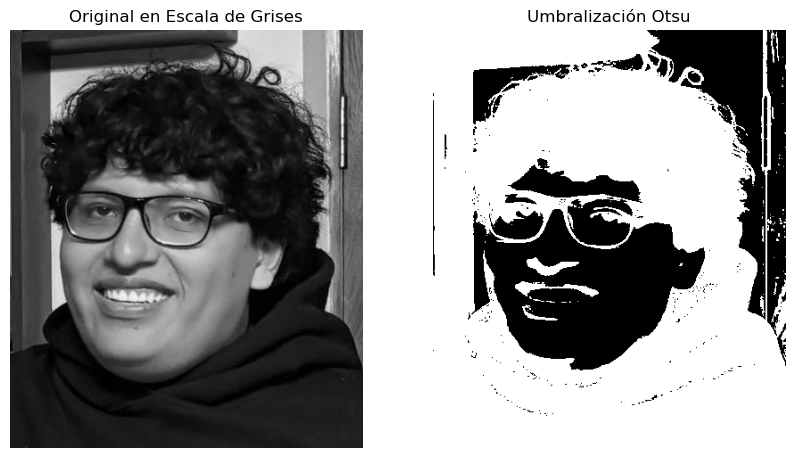

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
_, otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # podemos combinar diferentes umbralizaciones con una suma
imagen_fin = np.where(image > otsu, 255, 0).astype(np.uint8) # aplicamos el umbral de Otsu a la imagen original

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray') 
plt.axis('off')
plt.title('Original en Escala de Grises')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.axis('off')
plt.title(f'Umbralización Otsu')
plt.show()

UMBRALIZACION VARIABLE PARTICION DE UNA IMAGEN

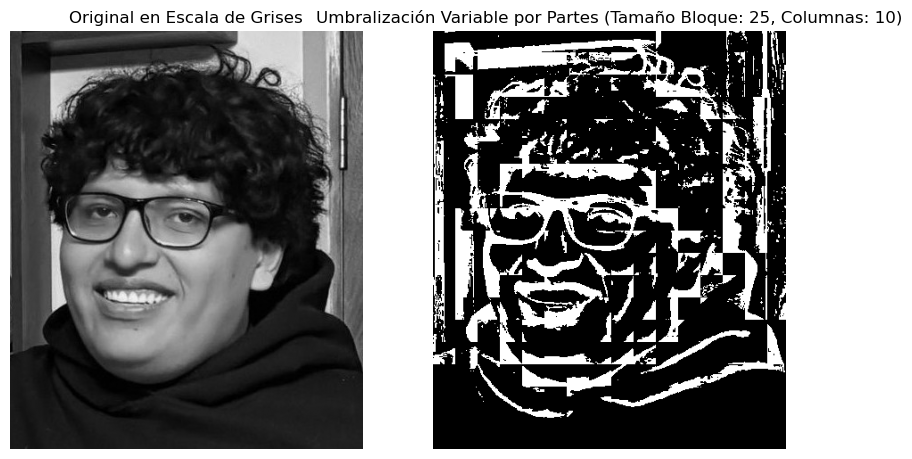

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_part(image, tamanio_bloque, columnas):
    umbral_img = np.zeros_like(image) 
    for y in range(0, image.shape[0], tamanio_bloque): # recorremos filas
        for x in range(0, image.shape[1], tamanio_bloque): # recorremos columnas
            bloque = image[y:y+tamanio_bloque, x:x+tamanio_bloque] # vemos el bloque
            bloq_media = np.mean(bloque) # intensidad del bloque
            umbral = bloq_media - columnas # restamos un valor a la media para obtener el umbral
            umbral_img[y:y+tamanio_bloque, x:x+tamanio_bloque] = (bloque > umbral) + 255

    return umbral_img

image = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
tamanio_bloque = 25 # podemos ajustar el tamaño del bloque para obtener diferentes resultados
columnas = 10 # podemos ajustar el valor que restamos a la media para obtener diferentes resultados
imagen_fin = variable_part(image, tamanio_bloque, columnas)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original en Escala de Grises')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.axis('off')
plt.title(f'Umbralización Variable por Partes (Tamaño Bloque: {tamanio_bloque}, Columnas: {columnas})')
plt.show()

PROPIEDADES LOCALES

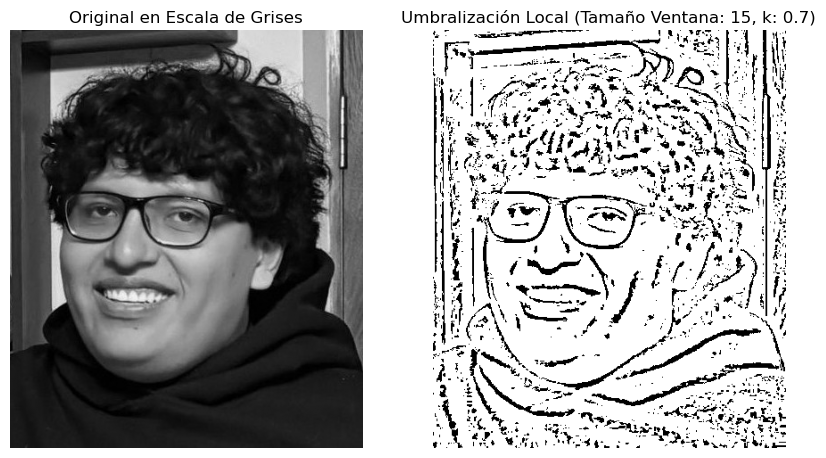

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
def local(image, tamanio_ventana, k):
    umbral_img = np.zeros_like(image)
    # Definir un rastreo de imagen con padding
    pad = tamanio_ventana // 2
    padded_image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    # Recorremos los pixeles
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana = padded_image[y:y+tamanio_ventana, x:x+tamanio_ventana]
            # calculo de media
            mean_local = np.mean(ventana) 
            std_mean = np.std(ventana)
            # calculo de umbral
            umbral = mean_local - (k * std_mean)
            umbral_img[y, x] = 255 if image[y, x] > umbral else 0
    return umbral_img

tamanio_ventana = 15 # podemos ajustar el tamaño de la ventana para obtener diferentes resultados
k = 0.7 # podemos ajustar el valor de k para obtener diferentes resultados
imagen_fin = local(image, tamanio_ventana, k)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original en Escala de Grises')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.axis('off')
plt.title(f'Umbralización Local (Tamaño Ventana: {tamanio_ventana}, k: {k})')
plt.show()

VARIABLE CON OPEN CV

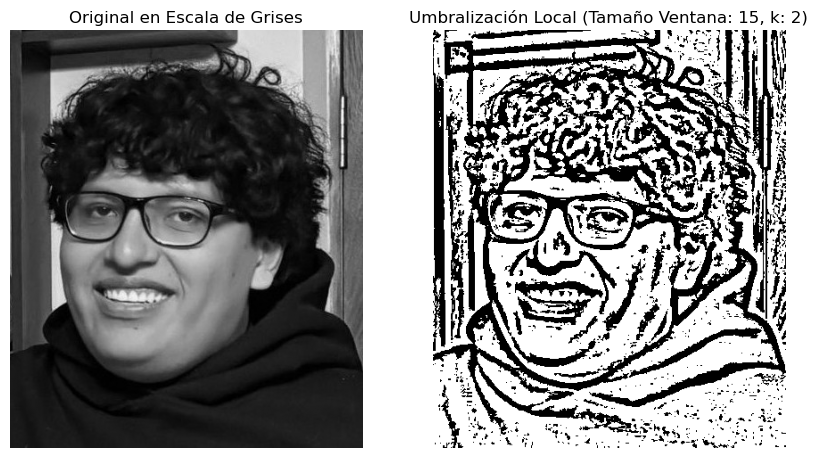

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
tamanio_ventana = 15 
k = 2 
imagen_fin = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, tamanio_ventana, k)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original en Escala de Grises')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.axis('off')
plt.title(f'Umbralización Local (Tamaño Ventana: {tamanio_ventana}, k: {k})')
plt.show()

ELABORACION DE CODIGO PROPIO DE COMO SE USA EL OTSU

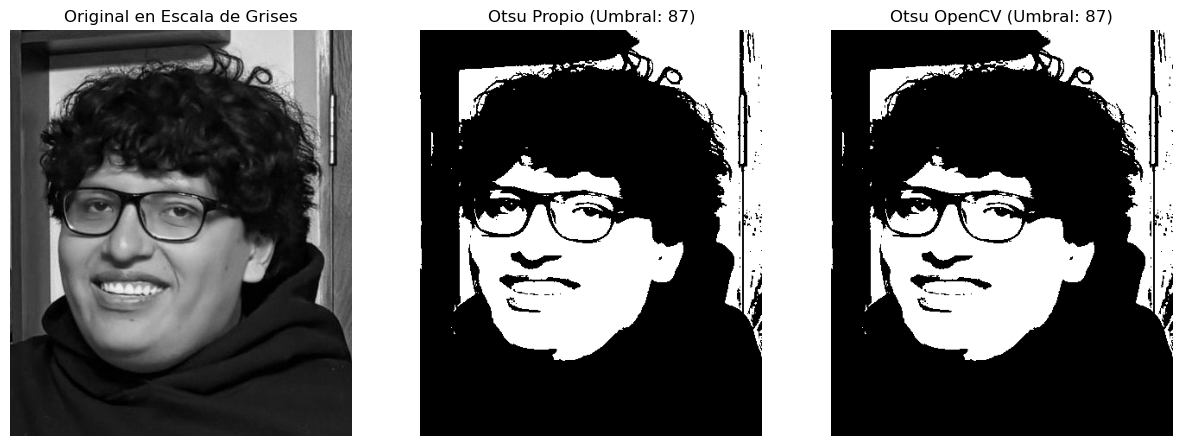

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_propio(imagen):
    histograma = cv2.calcHist([imagen], [0], None, [256], [0, 256]).flatten()
    total_pixeles = imagen.shape[0] * imagen.shape[1]
    suma_total_intensidades = np.sum(np.arange(256) * histograma)

    suma_fondo = 0.0
    peso_fondo = 0.0
    maxima_varianza_entre_clases = -1.0
    mejor_umbral = 0

    for umbral in range(256):
        peso_fondo += histograma[umbral]
        if peso_fondo == 0:
            continue

        peso_objeto = total_pixeles - peso_fondo
        if peso_objeto == 0:
            break

        suma_fondo += umbral * histograma[umbral]

        media_fondo = suma_fondo / peso_fondo
        media_objeto = (suma_total_intensidades - suma_fondo) / peso_objeto

        varianza_entre_clases = peso_fondo * peso_objeto * (media_fondo - media_objeto) ** 2

        if varianza_entre_clases > maxima_varianza_entre_clases:
            maxima_varianza_entre_clases = varianza_entre_clases
            mejor_umbral = umbral

    imagen_umbralizada = np.where(imagen > mejor_umbral, 255, 0).astype(np.uint8)

    return mejor_umbral, imagen_umbralizada


imagen = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)

umbral_otsu_propio, imagen_otsu_propia = otsu_propio(imagen)
umbral_otsu_cv2, imagen_otsu_cv2 = cv2.threshold(imagen, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap='gray')
plt.axis('off')
plt.title('Original en Escala de Grises')

plt.subplot(1, 3, 2)
plt.imshow(imagen_otsu_propia, cmap='gray')
plt.axis('off')
plt.title(f'Otsu Propio (Umbral: {umbral_otsu_propio})')

plt.subplot(1, 3, 3)
plt.imshow(imagen_otsu_cv2, cmap='gray')
plt.axis('off')
plt.title(f'Otsu OpenCV (Umbral: {int(umbral_otsu_cv2)})')

plt.show()